# Persiapan Dependencies dan GPU

In [1]:
import os, re

if "KAGGLE_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth

!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip install rouge_score -q
!pip install torchao>=0.16.0 -q  # fix kompatibilitas

print("Semua library berhasil diinstall!")

Semua library berhasil diinstall!


In [2]:
# Cek Versi Library
import subprocess

libraries = [
    "torch",
    "torchao",
    "unsloth",
    "transformers",
    "trl",
    "peft",
    "datasets",
    "accelerate",
    "bitsandbytes",
    "huggingface_hub",
    "wandb",
    "rouge_score",
    "sentencepiece",
    "xformers",
]

print("VERSI LIBRARY YANG TERINSTALL")

requirements = []
for lib in libraries:
    try:
        result = subprocess.run(
            ["pip", "show", lib],
            capture_output=True,
            text=True
        )
        # Ambil baris "Version: x.x.x"
        for line in result.stdout.split("\n"):
            if line.startswith("Version:"):
                version = line.split(": ")[1].strip()
                print(f"{lib:<20} == {version}")
                requirements.append(f"{lib}=={version}")
                break
    except Exception:
        print(f"{lib:<20} -- tidak ditemukan")

VERSI LIBRARY YANG TERINSTALL
torch                == 2.10.0+cu128
torchao              == 0.10.0
unsloth              == 2026.6.8
transformers         == 4.56.2
trl                  == 0.22.2
peft                 == 0.18.1
datasets             == 4.3.0
accelerate           == 1.13.0
bitsandbytes         == 0.49.2
huggingface_hub      == 0.36.2
wandb                == 0.25.1
rouge_score          == 0.1.2
sentencepiece        == 0.2.1
xformers             == 0.0.34


In [3]:
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template
from trl import SFTTrainer, SFTConfig
from transformers import TextStreamer
from datasets import load_dataset
from kaggle_secrets import UserSecretsClient 
import torch
import wandb
import os

if torch.cuda.is_available():
    gpu_stats        = torch.cuda.get_device_properties(0)
    start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
    max_memory       = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
    print(f"GPU Detected : {gpu_stats.name}")
    print(f"Max Memory   : {max_memory} GB")
    print(f"Used Memory  : {start_gpu_memory} GB")
else:
    print("WARNING: GPU Not Detected. Pastikan Accelerator sudah diaktifkan di Kaggle!")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2026-06-21 22:28:38.869525: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782080918.893250     727 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782080918.901038     727 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782080918.921632     727 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782080918.921651     727 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782080918.921660     727 computation_placer.cc:177] computation placer alr

🦥 Unsloth Zoo will now patch everything to make training faster!
GPU Detected : Tesla T4
Max Memory   : 14.562 GB
Used Memory  : 0.0 GB


# Login Huggingface dan Setup WandB

In [4]:
from huggingface_hub import login

secrets = UserSecretsClient()

# Login Hugging Face
hf_token = secrets.get_secret("HF_TOKEN")
login(token=hf_token)
print("Login HF berhasil!")

Login HF berhasil!


In [5]:
wandb_token = secrets.get_secret("WANDB_API_KEY")
os.environ["WANDB_API_KEY"] = wandb_token
print("WandB siap!")

WandB siap!


# Panggil Model dan Tokenizer

In [6]:
# Konfigurasi
MODEL_NAME     = "unsloth/Qwen2.5-3B-Instruct"
MAX_SEQ_LENGTH = 2048
DTYPE          = None
LOAD_IN_4BIT   = True

print(f"Memuat model: {MODEL_NAME}")

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
    load_in_4bit   = LOAD_IN_4BIT,   # mengaktifkan 4-bit + double quantization otomatis
    load_in_8bit   = False,
    full_finetuning= False,           # memastikan bukan full fine-tuning
    dtype          = DTYPE
)

Memuat model: unsloth/Qwen2.5-3B-Instruct
==((====))==  Unsloth 2026.6.8: Fast Qwen2 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


In [7]:
# Menggunakan chat template Qwen2.5
tokenizer = get_chat_template(
    tokenizer,
    chat_template = "qwen-2.5"
)

print(f"Model berhasil dimuat!")
print(f"Max Memory Used: {round(torch.cuda.max_memory_reserved()/1024/1024/1024, 3)} GB")

Model berhasil dimuat!
Max Memory Used: 2.949 GB


# Konfigurasi PEFT

In [8]:
model = FastLanguageModel.get_peft_model(
    model,
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",   # Multi-Head Attention
        "gate_proj", "up_proj", "down_proj"         # Feed Forward Network
    ],
    r                        = 16,        # rank LoRA Eksperimen 1
    lora_alpha               = 16,
    lora_dropout             = 0,
    bias                     = "none",
    use_gradient_checkpointing = "unsloth"
)

model.print_trainable_parameters()
# Harusnya ~1-2% dari total parameter

Unsloth 2026.6.8 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607


# Load & Mapping Dataset

In [9]:
# Load dataset Alpaca bahasa Indonesia
dataset = load_dataset("Ichsan2895/alpaca-gpt4-indonesian", split="train")
print(f"Total data: {len(dataset)}")

print("CONTOH DATA SEBELUM MAPPING:")
print(f"input       : {dataset[0]['input']}")
print(f"output      : {dataset[0]['output']}")

Total data: 49969
CONTOH DATA SEBELUM MAPPING:
input       : Saranlah slogan untuk kampanye daur ulang

output      : 1. "Kurangi, gunakan kembali, daur ulang: Bersama untuk masa depan yang lebih hijau."
2. "Daur ulanglah hari ini, untuk masa depan yang lebih baik."
3. "Ubah sampahmu menjadi harta karun - Daur ulang!"
4. "Daur ulang untuk siklus kehidupan."
5. "Simpan sumber daya, daur ulang lebih banyak."


In [10]:
system_prompt = "Anda adalah asisten AI yang membantu menjawab pertanyaan dalam bahasa Indonesia dengan jelas dan akurat."

def formatting_prompts_func(examples):
    inputs  = examples["input"]   # kolom input sudah berisi pertanyaan/instruksi
    outputs = examples["output"]
    texts   = []

    for input_text, output in zip(inputs, outputs):
        conversation = [
            {"role": "system",    "content": system_prompt},
            {"role": "user",      "content": input_text},
            {"role": "assistant", "content": output}
        ]

        text = tokenizer.apply_chat_template(
            conversation,
            tokenize              = False,
            add_generation_prompt = False
        )
        texts.append(text)

    return {"text": texts}

# Terapkan mapping
dataset_mapped = dataset.map(formatting_prompts_func, batched=True)

print("CONTOH DATA SETELAH MAPPING (dengan token spesial):")
print(dataset_mapped[0]["text"])

CONTOH DATA SETELAH MAPPING (dengan token spesial):
<|im_start|>system
Anda adalah asisten AI yang membantu menjawab pertanyaan dalam bahasa Indonesia dengan jelas dan akurat.<|im_end|>
<|im_start|>user
Saranlah slogan untuk kampanye daur ulang
<|im_end|>
<|im_start|>assistant
1. "Kurangi, gunakan kembali, daur ulang: Bersama untuk masa depan yang lebih hijau."
2. "Daur ulanglah hari ini, untuk masa depan yang lebih baik."
3. "Ubah sampahmu menjadi harta karun - Daur ulang!"
4. "Daur ulang untuk siklus kehidupan."
5. "Simpan sumber daya, daur ulang lebih banyak."<|im_end|>



# Split Data

In [11]:
dataset_split  = dataset_mapped.train_test_split(test_size=0.1, seed=42)
train_dataset  = dataset_split["train"]
eval_dataset   = dataset_split["test"]

print(f"Data training  : {len(train_dataset):,} baris")
print(f"Data validasi  : {len(eval_dataset):,} baris")

Data training  : 44,972 baris
Data validasi  : 4,997 baris


# Fine-tuning

## Eksperimen 1

In [13]:
wandb.init(
    project = "PGABL-Qwen2.5-3B",
    name    = "Exp1_lr2e4_rank16_cosine",
    reinit  = True,
)

print("Eksperimen 1: lr=2e-4 | rank=16 | scheduler=cosine | steps=800")
print("-" * 55)

sft_config_exp1 = SFTConfig(
    output_dir                  = "./results_exp1",
    per_device_train_batch_size = 2,      
    gradient_accumulation_steps = 4,        
    gradient_checkpointing      = False,
    warmup_steps                = 50,
    max_steps                   = 800,
    learning_rate               = 2e-4,
    lr_scheduler_type           = "cosine",
    fp16                        = not torch.cuda.is_bf16_supported(),
    bf16                        = torch.cuda.is_bf16_supported(),
    logging_steps               = 50,
    eval_strategy               = "steps",
    eval_steps                  = 200,     
    optim                       = "paged_adamw_8bit",
    dataset_text_field          = "text",
    max_length                  = 1024,      
    report_to                   = "wandb",
    run_name                    = "Exp1_lr2e4_rank16_cosine",
    save_strategy               = "no",
    seed                        = 42,
)

trainer_exp1 = SFTTrainer(
    model            = model,
    processing_class = tokenizer,
    train_dataset    = train_dataset,
    eval_dataset     = eval_dataset,
    args             = sft_config_exp1,
)

trainer_exp1.model.print_trainable_parameters()
trainer_stats_exp1 = trainer_exp1.train()

wandb.finish()
print(f"\nEksperimen 1 selesai!")
print(f"Training loss akhir: {trainer_stats_exp1.training_loss:.4f}")

Eksperimen 1: lr=2e-4 | rank=16 | scheduler=cosine | steps=800
-------------------------------------------------------


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/44972 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/4997 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 44,972 | Num Epochs = 1 | Total steps = 800
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)


Step,Training Loss,Validation Loss
200,1.101000,1.082633
400,1.056400,1.064908
600,1.061300,1.053691
800,1.031600,1.050788


Unsloth: Not an error, but Qwen2ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


eval/loss,█▄▂▁
eval/runtime,█▁▅▆
eval/samples_per_second,▁█▄▃
eval/steps_per_second,▁█▄▄
train/epoch,▁▁▂▂▂▃▃▄▄▄▅▅▆▆▆▇▇████
train/global_step,▁▁▂▂▂▃▃▄▄▄▅▅▆▆▆▇▇████
train/grad_norm,▂▅▁▅▄▄▆▂█▁▆▁▃▃▄▃
train/learning_rate,███▇▇▆▆▅▄▃▃▂▂▁▁▁
train/loss,█▃▂▂▂▂▂▁▁▁▁▂▂▂▂▁
eval/loss,1.05079
eval/runtime,626.9803



Eksperimen 1 selesai!
Training loss akhir: 1.0953


## Eksperimen 2

In [14]:
wandb.init(
    project = "PGABL-Qwen2.5-3B",
    name    = "Exp2_lr1e4_rank32_linear",
    reinit  = True,
)

model2, tokenizer2 = FastLanguageModel.from_pretrained(
    model_name      = MODEL_NAME,
    max_seq_length  = MAX_SEQ_LENGTH,
    load_in_4bit    = LOAD_IN_4BIT,
    load_in_8bit    = False,
    full_finetuning = False,
    dtype           = DTYPE
)

tokenizer2 = get_chat_template(tokenizer2, chat_template="qwen-2.5")

model2 = FastLanguageModel.get_peft_model(
    model2,
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    r                          = 32,     # BERBEDA: rank lebih besar
    lora_alpha                 = 32,
    lora_dropout               = 0,
    bias                       = "none",
    use_gradient_checkpointing = "unsloth"
)

print("Eksperimen 2: lr=1e-4 | rank=32 | scheduler=linear | steps=800")
print("-" * 55)

sft_config_exp2 = SFTConfig(
    output_dir                  = "./results_exp2",
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 4,
    gradient_checkpointing      = False,
    warmup_steps                = 100,      # BERBEDA: warmup lebih panjang
    max_steps                   = 800,
    learning_rate               = 1e-4,     # BERBEDA: lebih kecil
    lr_scheduler_type           = "linear", # BERBEDA: dari cosine
    fp16                        = not torch.cuda.is_bf16_supported(),
    bf16                        = torch.cuda.is_bf16_supported(),
    logging_steps               = 50,
    eval_strategy               = "steps",
    eval_steps                  = 200,
    optim                       = "paged_adamw_8bit",
    dataset_text_field          = "text",
    max_length                  = 1024,
    report_to                   = "wandb",
    run_name                    = "Exp2_lr1e4_rank32_linear",
    save_strategy               = "no",
    seed                        = 42,
)

trainer_exp2 = SFTTrainer(
    model            = model2,
    processing_class = tokenizer2,
    train_dataset    = train_dataset,
    eval_dataset     = eval_dataset,
    args             = sft_config_exp2,
)

trainer_exp2.model.print_trainable_parameters()
trainer_stats_exp2 = trainer_exp2.train()

wandb.finish()
print(f"\nEksperimen 2 selesai!")
print(f"Training loss akhir: {trainer_stats_exp2.training_loss:.4f}")

==((====))==  Unsloth 2026.6.8: Fast Qwen2 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
unsloth/qwen2.5-3b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Eksperimen 2: lr=1e-4 | rank=32 | scheduler=linear | steps=800
-------------------------------------------------------
trainable params: 59,867,136 || all params: 3,145,805,824 || trainable%: 1.9031


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 44,972 | Num Epochs = 1 | Total steps = 800
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 59,867,136 of 3,145,805,824 (1.90% trained)


Step,Training Loss,Validation Loss
200,1.104900,1.086211
400,1.059900,1.068082
600,1.065000,1.057307
800,1.032800,1.051910


eval/loss,█▄▂▁
eval/runtime,▁▅▁█
eval/samples_per_second,█▄█▁
eval/steps_per_second,█▄█▁
train/epoch,▁▁▂▂▂▃▃▄▄▄▅▅▆▆▆▇▇████
train/global_step,▁▁▂▂▂▃▃▄▄▄▅▅▆▆▆▇▇████
train/grad_norm,▂▅▁▅▄▄▆▂█▂▆▂▃▄▅▃
train/learning_rate,▄██▇▇▆▆▅▅▄▄▃▃▂▂▁
train/loss,█▃▂▂▂▂▂▁▁▁▁▁▁▂▂▁
eval/loss,1.05191
eval/runtime,1055.3144



Eksperimen 2 selesai!
Training loss akhir: 1.1056


# Perbandingan Kedua Eksperimen

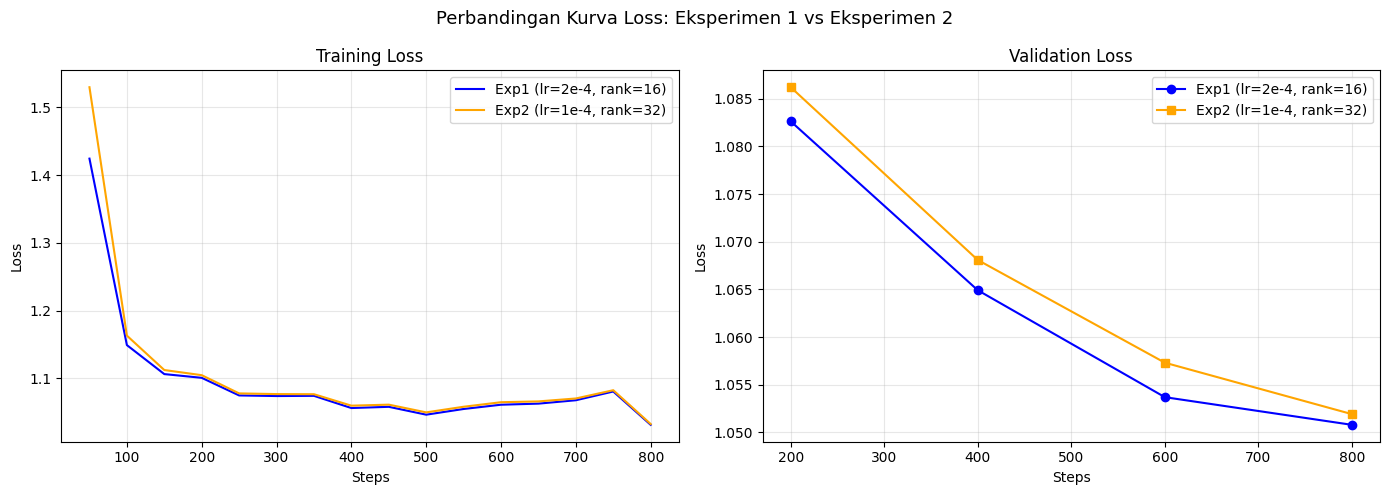

RINGKASAN PERBANDINGAN EKSPERIMEN
Exp 1 | lr=2e-4 | rank=16 | loss = 1.0953
Exp 2 | lr=1e-4 | rank=32 | loss = 1.1056

Model terbaik: Eksperimen 1 (lr=2e-4, rank=16)


In [15]:
import matplotlib.pyplot as plt

log_history_exp1 = trainer_exp1.state.log_history
log_history_exp2 = trainer_exp2.state.log_history

train_steps_1 = [x["step"] for x in log_history_exp1 if "loss" in x]
train_loss_1  = [x["loss"] for x in log_history_exp1 if "loss" in x]
train_steps_2 = [x["step"] for x in log_history_exp2 if "loss" in x]
train_loss_2  = [x["loss"] for x in log_history_exp2 if "loss" in x]

eval_steps_1  = [x["step"]      for x in log_history_exp1 if "eval_loss" in x]
eval_loss_1   = [x["eval_loss"] for x in log_history_exp1 if "eval_loss" in x]
eval_steps_2  = [x["step"]      for x in log_history_exp2 if "eval_loss" in x]
eval_loss_2   = [x["eval_loss"] for x in log_history_exp2 if "eval_loss" in x]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_steps_1, train_loss_1, label="Exp1 (lr=2e-4, rank=16)", color="blue")
axes[0].plot(train_steps_2, train_loss_2, label="Exp2 (lr=1e-4, rank=32)", color="orange")
axes[0].set_title("Training Loss"); axes[0].set_xlabel("Steps")
axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(eval_steps_1, eval_loss_1, label="Exp1 (lr=2e-4, rank=16)", color="blue", marker="o")
axes[1].plot(eval_steps_2, eval_loss_2, label="Exp2 (lr=1e-4, rank=32)", color="orange", marker="s")
axes[1].set_title("Validation Loss"); axes[1].set_xlabel("Steps")
axes[1].set_ylabel("Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Perbandingan Kurva Loss: Eksperimen 1 vs Eksperimen 2", fontsize=13)
plt.tight_layout()
plt.show()

print("="*55)
print("RINGKASAN PERBANDINGAN EKSPERIMEN")
print("="*55)
print(f"Exp 1 | lr=2e-4 | rank=16 | loss = {trainer_stats_exp1.training_loss:.4f}")
print(f"Exp 2 | lr=1e-4 | rank=32 | loss = {trainer_stats_exp2.training_loss:.4f}")

# Pilih model dengan training loss terendah
if trainer_stats_exp1.training_loss <= trainer_stats_exp2.training_loss:
    best_model, best_tokenizer = model, tokenizer
    print("\nModel terbaik: Eksperimen 1 (lr=2e-4, rank=16)")
else:
    best_model, best_tokenizer = model2, tokenizer2
    print("\nModel terbaik: Eksperimen 2 (lr=1e-4, rank=32)")

# Upload ke HuggingFace

In [16]:
HF_USERNAME     = "Rahmat15"
MODEL_REPO_NAME = "qwen2.5-3b-indonesian-legal"
FULL_REPO_NAME  = f"{HF_USERNAME}/{MODEL_REPO_NAME}"

print(f"Mengupload ke: {FULL_REPO_NAME}")
print("Proses ini 10-20 menit, jangan tutup Colab...")

best_model.push_to_hub_merged(
    FULL_REPO_NAME,
    tokenizer   = best_tokenizer,
    save_method = "merged_16bit"
)

print(f"\nUpload selesai!")
print(f"https://huggingface.co/{FULL_REPO_NAME}")
print("\nSalin link di atas ke file link_huggingface.txt!")

Mengupload ke: Rahmat15/qwen2.5-3b-indonesian-legal
Proses ini 10-20 menit, jangan tutup Colab...


config.json:   0%|          | 0.00/757 [00:00<?, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


...

Unsloth: Merging weights into 16bit:  50%|█████     | 1/2 [01:24<01:24, 84.19s/it]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [02:07<00:00, 63.72s/it]


Unsloth: Merge process complete. Saved to `/kaggle/working/Rahmat15/qwen2.5-3b-indonesian-legal`

Upload selesai!
https://huggingface.co/Rahmat15/qwen2.5-3b-indonesian-legal

Salin link di atas ke file link_huggingface.txt!


# Inference

In [17]:
FastLanguageModel.for_inference(best_model)

messages = [
    {"role": "system",  "content": "Anda adalah asisten AI yang membantu menjawab pertanyaan dalam bahasa Indonesia dengan jelas dan akurat."},
    {"role": "user",    "content": "Sebutkan 3 candi terkenal di Indonesia beserta lokasinya!"}
]

inputs = best_tokenizer.apply_chat_template(
    messages,
    tokenize              = True,
    add_generation_prompt = True,
    return_tensors        = "pt"
).to("cuda")

text_streamer = TextStreamer(best_tokenizer, skip_prompt=True)

print("Jawaban model:")
print("-" * 40)
_ = best_model.generate(
    input_ids         = inputs,
    streamer          = text_streamer,
    max_new_tokens    = 256,
    temperature       = 0.3,
    repetition_penalty= 1.2,
    do_sample         = True,
    eos_token_id      = best_tokenizer.eos_token_id,
    pad_token_id      = best_tokenizer.eos_token_id
)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Jawaban model:
----------------------------------------
1) Borobudur: Terletak di Magelang, Jawa Tengah.
2) Candi Prambanan: Berlokasi di Yogjakarta, Daerah Istimewa Yogyakartaa.
3) Candi Bubungan: Ditempatkan di Semarang, Provinsi Jatimarko.<|im_end|>


In [18]:
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="Rahmat15/qwen2.5-3b-indonesian-legal",
    max_seq_length=2048,
    load_in_4bit=True,
)

==((====))==  Unsloth 2026.6.8: Fast Qwen2 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.97G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/632 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/499 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]